# Cuaderno de entrenamiento para detección de carriles

Este cuaderno reutiliza la estructura del notebook anterior, pero ahora está adaptado al proyecto de detección de carriles en carretera. El objetivo es entrenar y comparar tres modelos de deep learning para segmentación binaria de carriles usando el contenido de la carpeta `Dataset`, donde cada muestra debe incluir una imagen de carretera y su máscara de carril correspondiente.

El cuaderno está organizado de la siguiente manera:

- Indexación del dataset y EDA básico
- Preprocesamiento y partición train/validation/test
- Transformaciones conjuntas de imagen y máscara
- Entrenamiento, validación y comparación de modelos
- Evaluación final del mejor modelo
- Ejemplos visuales y serialización


In [1]:
import copy
import json
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from PIL import Image
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from torchvision.models import ResNet50_Weights
from torchvision.models.segmentation import (
    deeplabv3_resnet50,
    fcn_resnet50,
)
from tqdm.auto import tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Configuración

La configuración siguiente centraliza la ruta del dataset, el tamaño de imagen, los parámetros de optimización y la búsqueda compacta de hiperparámetros. Los valores están pensados para que el notebook sea práctico de ejecutar y, al mismo tiempo, permita una comparación útil entre los modelos.


In [3]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

project_root = Path.cwd()

if (project_root / "Dataset").is_dir():
    DATA_ROOT = project_root / "Dataset"
elif (project_root.parent / "Dataset").is_dir():
    DATA_ROOT = project_root.parent / "Dataset"
else:
    raise FileNotFoundError("Expected a folder named 'Dataset' in the current directory or its parent.")

CULANE_FORMATTED_ROOT = DATA_ROOT / "CULane_formateado"

if not CULANE_FORMATTED_ROOT.is_dir():
    raise FileNotFoundError(f"Expected CULane_formateado at {CULANE_FORMATTED_ROOT.resolve()}")

base_path = CULANE_FORMATTED_ROOT
data_base_path = str(base_path)

model_output_dir = Path("./trained_models")
model_output_dir.mkdir(parents=True, exist_ok=True)

print(f"Dataset root: {DATA_ROOT.resolve()}")
print(f"CULane_formateado root: {CULANE_FORMATTED_ROOT.resolve()} | exists={CULANE_FORMATTED_ROOT.is_dir()}")

image_size = 256
num_workers = 0
default_threshold = 0.5

search_epochs = 4
final_epochs = 12

train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

hyperparameter_grid = {
    "UNet": [
        {"batch_size": 8, "lr": 1e-3, "weight_decay": 1e-4},
        {"batch_size": 8, "lr": 3e-4, "weight_decay": 1e-4},
    ],
    "FCNResNet50": [
        {"batch_size": 4, "lr": 1e-4, "weight_decay": 1e-4},
        {"batch_size": 4, "lr": 3e-4, "weight_decay": 1e-4},
    ],
    "DeepLabV3ResNet50": [
        {"batch_size": 4, "lr": 1e-4, "weight_decay": 1e-4},
        {"batch_size": 4, "lr": 3e-4, "weight_decay": 1e-4},
    ],
}


Dataset root: C:\Users\Rafael\Documents\GitHub\lane-locator\Dataset
CULane_formateado root: C:\Users\Rafael\Documents\GitHub\lane-locator\Dataset\CULane_formateado | exists=True


## Indexación del dataset

La carpeta del dataset debe contener una subcarpeta por muestra. Cada subcarpeta debe incluir, al menos, una imagen original de la carretera y su máscara de carril. Esta sección construye una tabla compacta con las rutas que se usarán tanto en el EDA como en el entrenamiento.


In [4]:
if not base_path.is_dir():
    raise FileNotFoundError(f"Expected dataset at {base_path.resolve()}")


def find_first_match(folder: Path, patterns):
    for pattern in patterns:
        match = next(folder.glob(pattern), None)
        if match is not None:
            return match
    return None


def load_v1_index(base_path):
    valid_suffixes = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    def pick_file(sample_folder, keyword):
        matches = []
        for f in sample_folder.iterdir():
            if not f.is_file():
                continue
            if f.suffix.lower() not in valid_suffixes:
                continue

            name = f.name.lower()
            if keyword in name:
                matches.append(f)

        if len(matches) == 0:
            return None

        matches = sorted(matches)
        return matches[0]

    sample_folders = [
        p for p in sorted(base_path.rglob("*"))
        if p.is_dir() and any(f.is_file() for f in p.iterdir())
    ]

    rows = []

    for sample_folder in sample_folders:
        raw = pick_file(sample_folder, "raw")
        lane = pick_file(sample_folder, "lane")
        crack = pick_file(sample_folder, "crack")
        pothole = pick_file(sample_folder, "pothole")

        if raw is None or lane is None:
            continue

        rows.append(
            {
                "sample_id": str(sample_folder.relative_to(base_path)),
                "capture_type": sample_folder.parent.name,
                "raw": str(raw),
                "lane_mask": str(lane),
                "crack_mask": str(crack) if crack else None,
                "pothole_mask": str(pothole) if pothole else None,
            }
        )

    df = pd.DataFrame(rows)

    if len(df) == 0:
        raise ValueError("No valid samples were found. Each sample folder must include a raw image and a lane mask.")

    return df


df = load_v1_index(base_path)
df.head()


,sample_id,capture_type,raw,lane_mask,crack_mask,pothole_mask
0,CULane-20260423T032032Z-3-007__CULane__driver_...,CULane_formateado,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,None
1,CULane-20260423T032032Z-3-007__CULane__driver_...,CULane_formateado,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,None
2,CULane-20260423T032032Z-3-007__CULane__driver_...,CULane_formateado,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,None
3,CULane-20260423T032032Z-3-007__CULane__driver_...,CULane_formateado,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,None
4,CULane-20260423T032032Z-3-007__CULane__driver_...,CULane_formateado,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,None


## EDA básico

Estas celdas resumen el dataset y verifican que las imágenes originales y las máscaras de carril estén alineadas. En segmentación, estadísticas como el tamaño de imagen, la cobertura de foreground y la inspección visual rápida son especialmente útiles para anticipar posibles problemas antes del entrenamiento.


In [5]:
print(f"Number of samples: {len(df):,}")
print()
print("Missing files per column:")
print(df[["raw", "lane_mask", "crack_mask", "pothole_mask"]].isna().sum())

Number of samples: 62,673

Missing files per column:
raw                 0
lane_mask           0
crack_mask          0
pothole_mask    62673
dtype: int64


In [6]:
def image_size_from_path(path: str):
    with Image.open(path) as image:
        return image.size


def foreground_ratio(path: str):
    mask = np.asarray(Image.open(path).convert("L"))
    return float((mask > 0).mean())


sizes = df["raw"].map(image_size_from_path)
df["width"] = sizes.map(lambda item: item[0])
df["height"] = sizes.map(lambda item: item[1])
df["lane_fg_ratio"] = df["lane_mask"].map(foreground_ratio)

sample_parts = df["sample_id"].astype(str).str.split("_", n=3, expand=True)
if sample_parts.shape[1] > 1:
    df["capture_type"] = sample_parts[1]
else:
    df["capture_type"] = "unknown"

display(df[["width", "height", "lane_fg_ratio"]].describe().round(4))
display(df["capture_type"].value_counts(dropna=False).rename_axis("capture_type").to_frame("count"))

,width,height,lane_fg_ratio
count,62673.0,62673.0,62673.0000
mean,1640.0,590.0,0.1214
std,0.0,0.0,0.0439
min,1640.0,590.0,0.0060
25%,1640.0,590.0,0.0766
50%,1640.0,590.0,0.1290
75%,1640.0,590.0,0.1538
max,1640.0,590.0,0.2958


,count
capture_type,
161,16210
100,15842
182,15710
193,12076
,2835


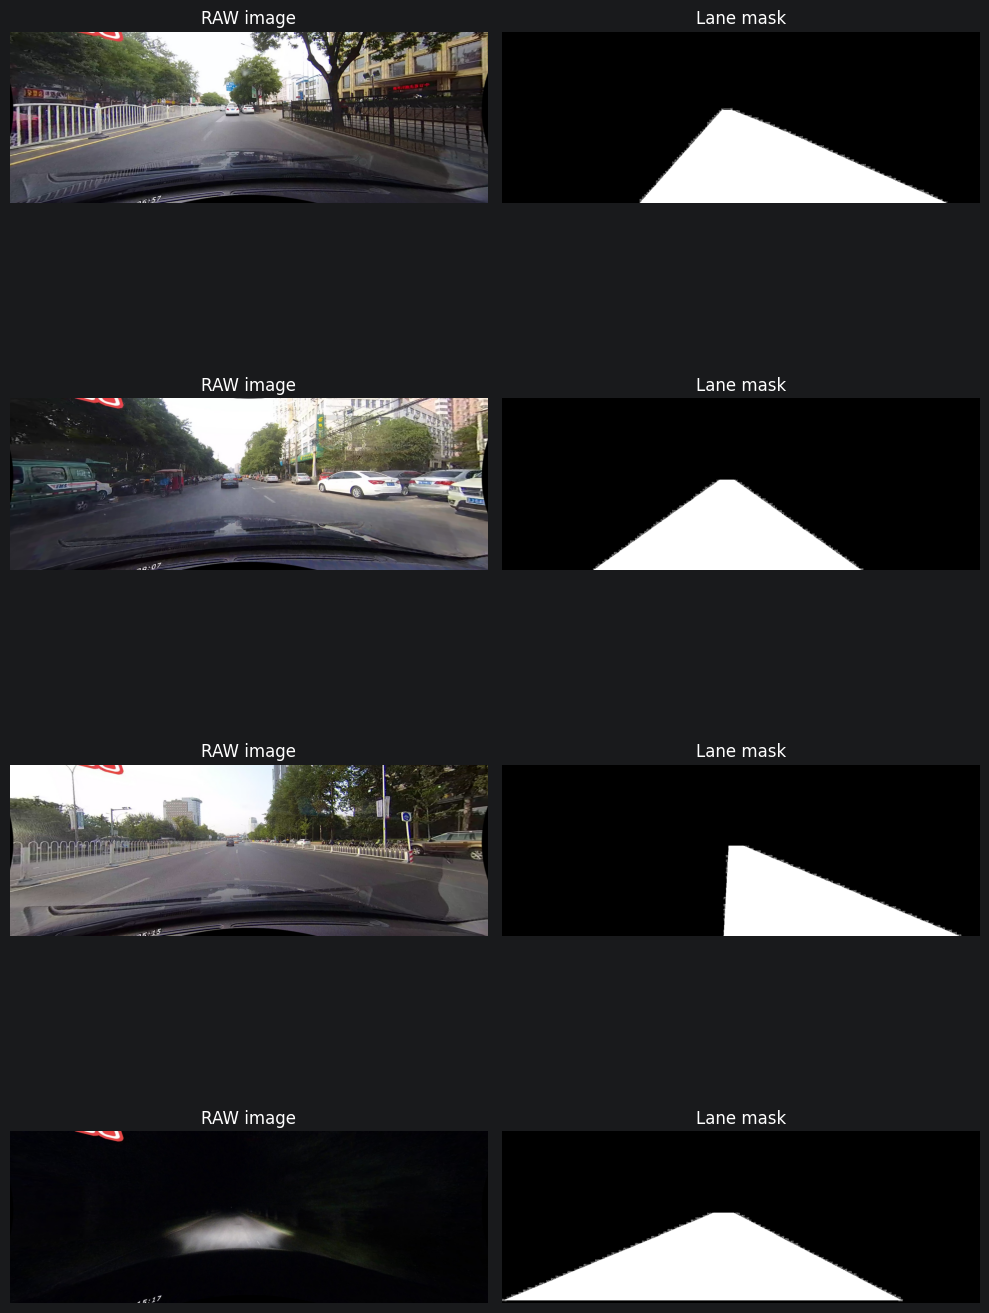

In [7]:
rng = np.random.default_rng()
picked = rng.choice(len(df), size=min(4, len(df)), replace=False)

fig, axes = plt.subplots(len(picked), 2, figsize=(10, 4 * len(picked)))
if len(picked) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, idx in enumerate(picked):
    sample = df.iloc[int(idx)]
    image = np.asarray(Image.open(sample["raw"]).convert("RGB"))
    mask = np.asarray(Image.open(sample["lane_mask"]).convert("L")) > 0

    axes[row, 0].imshow(image)
    axes[row, 0].set_title("RAW image")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("Lane mask")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

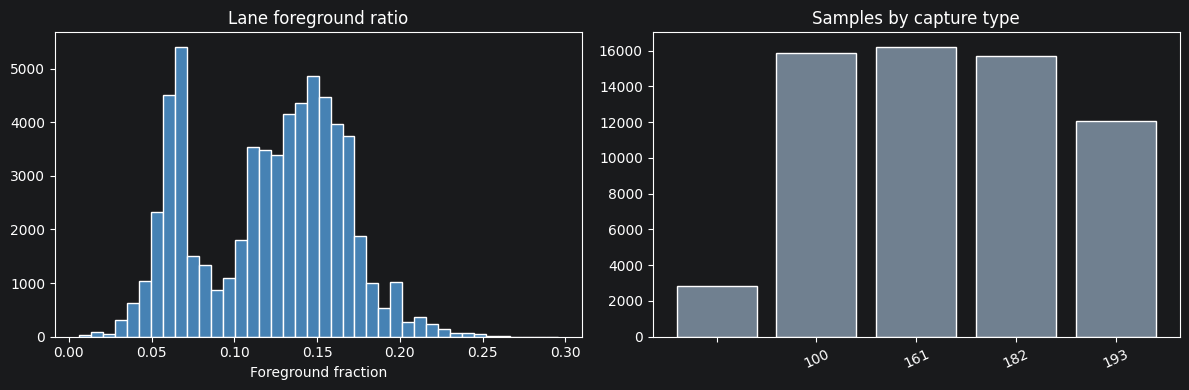

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["lane_fg_ratio"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Lane foreground ratio")
axes[0].set_xlabel("Foreground fraction")

capture_counts = df["capture_type"].value_counts().sort_index()
axes[1].bar(capture_counts.index.astype(str), capture_counts.values, color="slategray", edgecolor="white")
axes[1].set_title("Samples by capture type")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## Preparación del split

La partición se realiza a nivel de muestra y utiliza una clave de estratificación basada en la cobertura del carril y el tipo de captura. Esto ayuda a mantener train, validation y test más equilibrados que un split completamente aleatorio, lo cual es importante cuando la visibilidad de los carriles cambia bastante entre muestras.


In [9]:
coverage_bins = pd.qcut(df["lane_fg_ratio"], q=min(5, df["lane_fg_ratio"].nunique()), duplicates="drop")
df["coverage_bin"] = coverage_bins.astype(str)
df["stratify_key"] = df["capture_type"].astype(str) + "__" + df["coverage_bin"].astype(str)

stratify_counts = df["stratify_key"].value_counts()
rare_keys = stratify_counts[stratify_counts < 3].index
df.loc[df["stratify_key"].isin(rare_keys), "stratify_key"] = "fallback"

train_df, temp_df = train_test_split(
    df,
    test_size=(1.0 - train_ratio),
    random_state=None,
    shuffle=True,
    stratify=df["stratify_key"] if df["stratify_key"].nunique() > 1 else None,
)

relative_test_ratio = test_ratio / (val_ratio + test_ratio)

temp_stratify = temp_df["stratify_key"].copy()

temp_counts = temp_stratify.value_counts()
temp_rare_keys = temp_counts[temp_counts < 2].index
temp_stratify.loc[temp_stratify.isin(temp_rare_keys)] = "fallback"

temp_counts_after = temp_stratify.value_counts()

if temp_stratify.nunique() <= 1 or (temp_counts_after < 2).any():
    temp_stratify = None

val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_ratio,
    random_state=None,
    shuffle=True,
    stratify=temp_stratify,
)

split_df = pd.DataFrame(
    {
        "train": [len(train_df)],
        "validation": [len(val_df)],
        "test": [len(test_df)],
    }
)
split_df

,train,validation,test
0,50138,6267,6268


In [10]:
def split_distribution(frame: pd.DataFrame, column_name: str):
    return frame[column_name].value_counts().sort_index()

coverage_distribution = pd.DataFrame(
    {
        "train": split_distribution(train_df, "coverage_bin"),
        "validation": split_distribution(val_df, "coverage_bin"),
        "test": split_distribution(test_df, "coverage_bin"),
    }
).fillna(0).astype(int)

capture_distribution = pd.DataFrame(
    {
        "train": split_distribution(train_df, "capture_type"),
        "validation": split_distribution(val_df, "capture_type"),
        "test": split_distribution(test_df, "capture_type"),
    }
).fillna(0).astype(int)

display(coverage_distribution)
display(capture_distribution)

,train,validation,test
coverage_bin,,,
"(0.00501, 0.0688]",10042,1271,1239
"(0.0688, 0.115]",10013,1252,1252
"(0.115, 0.139]",10029,1293,1214
"(0.139, 0.16]",10026,1208,1299
"(0.16, 0.296]",10028,1243,1264


,train,validation,test
capture_type,,,
,2268,273,294
100,12674,1603,1565
161,12968,1625,1617
182,12567,1602,1541
193,9661,1164,1251


## Preprocesamiento conjunto para imagen y máscara

A diferencia de clasificación de imágenes, en segmentación se requieren transformaciones emparejadas para que la imagen y la máscara pasen por las mismas operaciones espaciales. La máscara se convierte a un tensor binario con forma `[1, H, W]`, mientras que la imagen se normaliza con estadísticas de ImageNet porque algunos modelos usan backbones relacionados con ese preentrenamiento.


In [11]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class JointSegmentationTransform:
    def __init__(self, image_size=256, train=False):
        self.image_size = image_size
        self.train = train

    def __call__(self, image, mask):
        image = image.convert("RGB")
        mask = mask.convert("L")

        image = TF.resize(image, [self.image_size, self.image_size])
        mask = TF.resize(mask, [self.image_size, self.image_size], interpolation=TF.InterpolationMode.NEAREST)

        if self.train and random.random() < 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        if self.train and random.random() < 0.3:
            angle = random.uniform(-8, 8)
            image = TF.rotate(image, angle)
            mask = TF.rotate(mask, angle, interpolation=TF.InterpolationMode.NEAREST)

        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=IMAGENET_MEAN, std=IMAGENET_STD)

        mask = torch.from_numpy((np.asarray(mask) > 0).astype(np.float32)).unsqueeze(0)

        return image, mask


train_transform = JointSegmentationTransform(image_size=image_size, train=True)
eval_transform = JointSegmentationTransform(image_size=image_size, train=False)

In [12]:
class LaneSegmentationDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform=None):
        self.frame = frame.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row["raw"])
        mask = Image.open(row["lane_mask"])

        if self.transform is not None:
            image, mask = self.transform(image, mask)

        x = image.to(device)
        y = mask.to(device)
        return x, y


train_data = LaneSegmentationDataset(train_df, transform=train_transform)
val_data = LaneSegmentationDataset(val_df, transform=eval_transform)
test_data = LaneSegmentationDataset(test_df, transform=eval_transform)

## Función de pérdida, métricas y ciclo de entrenamiento

El ciclo de entrenamiento registra tanto la optimización como la calidad de segmentación. La métrica principal de selección en este notebook es Dice en validation, mientras que IoU y pixel accuracy también se calculan para tener una visión más completa del comportamiento de cada modelo.


In [13]:
def sigmoid_to_mask(logits, threshold=default_threshold):
    probabilities = torch.sigmoid(logits)
    return (probabilities >= threshold).float()


def dice_score_from_logits(logits, targets, threshold=default_threshold, eps=1e-6):
    predictions = sigmoid_to_mask(logits, threshold=threshold)
    intersection = (predictions * targets).sum(dim=(1, 2, 3))
    union = predictions.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean().item()


def iou_score_from_logits(logits, targets, threshold=default_threshold, eps=1e-6):
    predictions = sigmoid_to_mask(logits, threshold=threshold)
    intersection = (predictions * targets).sum(dim=(1, 2, 3))
    union = predictions.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()


def pixel_accuracy_from_logits(logits, targets, threshold=default_threshold):
    predictions = sigmoid_to_mask(logits, threshold=threshold)
    correct = predictions.eq(targets).float().mean()
    return correct.item()


class DiceBCELoss(nn.Module):
    def __init__(self, pos_weight=None):
        super().__init__()
        if pos_weight is not None:
            self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        else:
            self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce = self.bce(logits, targets)
        probabilities = torch.sigmoid(logits)
        intersection = (probabilities * targets).sum(dim=(1, 2, 3))
        union = probabilities.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
        dice_loss = 1.0 - ((2 * intersection + 1e-6) / (union + 1e-6)).mean()
        return bce + dice_loss

In [14]:
def build_dataloaders(batch_size):
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, val_loader, test_loader


def estimate_positive_weight(frame: pd.DataFrame):
    ratios = frame["lane_fg_ratio"].to_numpy(dtype=np.float32)
    positive_fraction = float(np.clip(ratios.mean(), 1e-4, 1.0 - 1e-4))
    negative_fraction = 1.0 - positive_fraction
    return torch.tensor([negative_fraction / positive_fraction], dtype=torch.float32, device=device)


def extract_logits(model_output):
    if isinstance(model_output, dict):
        return model_output["out"]
    return model_output


def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_pixel_acc = 0.0
    total_items = 0

    all_true = []
    all_pred = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = extract_logits(model(X_batch))
            loss = criterion(logits, y_batch)

            batch_size = X_batch.size(0)
            total_loss += loss.item() * batch_size
            total_dice += dice_score_from_logits(logits, y_batch) * batch_size
            total_iou += iou_score_from_logits(logits, y_batch) * batch_size
            total_pixel_acc += pixel_accuracy_from_logits(logits, y_batch) * batch_size
            total_items += batch_size

            predictions = sigmoid_to_mask(logits).detach().cpu().numpy().astype(np.uint8).ravel()
            targets = y_batch.detach().cpu().numpy().astype(np.uint8).ravel()
            all_pred.append(predictions)
            all_true.append(targets)

    all_true = np.concatenate(all_true)
    all_pred = np.concatenate(all_pred)

    return {
        "loss": total_loss / total_items,
        "dice": total_dice / total_items,
        "iou": total_iou / total_items,
        "pixel_acc": total_pixel_acc / total_items,
        "y_true_pixels": all_true,
        "y_pred_pixels": all_pred,
    }


def train(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    history = {
        "train_loss": [],
        "train_dice": [],
        "train_iou": [],
        "train_pixel_acc": [],
        "val_loss": [],
        "val_dice": [],
        "val_iou": [],
        "val_pixel_acc": [],
    }

    best_state_dict = copy.deepcopy(model.state_dict())
    best_val_dice = -1.0

    iterator = tqdm(range(num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        model.train()

        total_loss = 0.0
        total_dice = 0.0
        total_iou = 0.0
        total_pixel_acc = 0.0
        total_items = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            logits = extract_logits(model(X_batch))
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            batch_size = X_batch.size(0)
            total_loss += loss.item() * batch_size
            total_dice += dice_score_from_logits(logits, y_batch) * batch_size
            total_iou += iou_score_from_logits(logits, y_batch) * batch_size
            total_pixel_acc += pixel_accuracy_from_logits(logits, y_batch) * batch_size
            total_items += batch_size

        epoch_train_loss = total_loss / total_items
        epoch_train_dice = total_dice / total_items
        epoch_train_iou = total_iou / total_items
        epoch_train_pixel_acc = total_pixel_acc / total_items

        val_res = evaluate(model, val_loader, criterion)

        history["train_loss"].append(epoch_train_loss)
        history["train_dice"].append(epoch_train_dice)
        history["train_iou"].append(epoch_train_iou)
        history["train_pixel_acc"].append(epoch_train_pixel_acc)

        history["val_loss"].append(val_res["loss"])
        history["val_dice"].append(val_res["dice"])
        history["val_iou"].append(val_res["iou"])
        history["val_pixel_acc"].append(val_res["pixel_acc"])

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            val_loss=f"{val_res['loss']:.4f}",
            val_dice=f"{val_res['dice']:.4f}",
        )

        if val_res["dice"] > best_val_dice:
            best_val_dice = val_res["dice"]
            best_state_dict = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state_dict)
    return history

In [15]:
def plot_learning_curves(history, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"], label="validation")
    axes[0].set_title(f"{title} - loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history["train_dice"], label="train")
    axes[1].plot(history["val_dice"], label="validation")
    axes[1].set_title(f"{title} - Dice")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    axes[2].plot(history["train_iou"], label="train")
    axes[2].plot(history["val_iou"], label="validation")
    axes[2].set_title(f"{title} - IoU")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

## Definición de modelos

El notebook compara tres arquitecturas de segmentación relacionadas con la detección de carriles:

- UNet
- FCN-ResNet50
- DeepLabV3-ResNet50

Cada modelo predice una sola máscara binaria de carril.


In [16]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=(64, 128, 256, 512)):
        super().__init__()

        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        current_channels = in_channels
        for feature in features:
            self.downs.append(DoubleConv(current_channels, feature))
            current_channels = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        reversed_features = list(features[::-1])
        up_channels = features[-1] * 2
        for feature in reversed_features:
            self.ups.append(nn.ConvTranspose2d(up_channels, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature * 2, feature))
            up_channels = feature

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skip_connections[idx // 2]

            if x.shape != skip.shape:
                x = TF.resize(x, [skip.shape[2], skip.shape[3]])

            concat = torch.cat((skip, x), dim=1)
            x = self.ups[idx + 1](concat)

        return self.final_conv(x)


def build_model(model_name):
    if model_name == "UNet":
        return UNet().to(device)

    if model_name == "FCNResNet50":
        try:
            return fcn_resnet50(weights=None, weights_backbone=ResNet50_Weights.DEFAULT, num_classes=1).to(device)
        except:
            return fcn_resnet50(weights=None, weights_backbone=None, num_classes=1).to(device)

    if model_name == "DeepLabV3ResNet50":
        try:
            return deeplabv3_resnet50(weights=None, weights_backbone=ResNet50_Weights.DEFAULT, num_classes=1).to(device)
        except:
            return deeplabv3_resnet50(weights=None, weights_backbone=None, num_classes=1).to(device)

    raise ValueError(f"Unknown model name: {model_name}")

## Búsqueda de hiperparámetros

Para cada modelo, el notebook evalúa un conjunto pequeño de hiperparámetros candidatos y conserva la configuración con mayor Dice en validation. Después, cada modelo se reentrena con su mejor configuración durante el número completo de épocas.


In [17]:
positive_weight = estimate_positive_weight(train_df)
positive_weight

tensor([7.2366])

In [18]:
def run_hyperparameter_search(model_name, configs):
    rows = []

    for config in configs:
        train_loader, val_loader, _ = build_dataloaders(config["batch_size"])
        model = build_model(model_name)
        criterion = DiceBCELoss(pos_weight=positive_weight)
        optimizer = AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])

        history = train(model, train_loader, val_loader, criterion, optimizer, search_epochs)
        best_val_dice = max(history["val_dice"])
        best_val_iou = max(history["val_iou"])

        rows.append(
            {
                "model": model_name,
                "batch_size": config["batch_size"],
                "lr": config["lr"],
                "weight_decay": config["weight_decay"],
                "search_best_val_dice": best_val_dice,
                "search_best_val_iou": best_val_iou,
            }
        )

    search_df = pd.DataFrame(rows).sort_values("search_best_val_dice", ascending=False).reset_index(drop=True)
    best_config = search_df.iloc[0][["batch_size", "lr", "weight_decay"]].to_dict()
    return search_df, best_config


def run_final_training(model_name, best_config):
    train_loader, val_loader, test_loader = build_dataloaders(int(best_config["batch_size"]))
    model = build_model(model_name)
    criterion = DiceBCELoss(pos_weight=positive_weight)
    optimizer = AdamW(model.parameters(), lr=float(best_config["lr"]), weight_decay=float(best_config["weight_decay"]))

    history = train(model, train_loader, val_loader, criterion, optimizer, final_epochs)

    train_res = evaluate(model, train_loader, criterion)
    val_res = evaluate(model, val_loader, criterion)
    test_res = evaluate(model, test_loader, criterion)

    metrics = {
        "experiment": model_name,
        "batch_size": int(best_config["batch_size"]),
        "lr": float(best_config["lr"]),
        "weight_decay": float(best_config["weight_decay"]),
        "train_loss": train_res["loss"],
        "train_dice": train_res["dice"],
        "train_iou": train_res["iou"],
        "train_pixel_acc": train_res["pixel_acc"],
        "val_loss": val_res["loss"],
        "val_dice": val_res["dice"],
        "val_iou": val_res["iou"],
        "val_pixel_acc": val_res["pixel_acc"],
        "test_loss": test_res["loss"],
        "test_dice": test_res["dice"],
        "test_iou": test_res["iou"],
        "test_pixel_acc": test_res["pixel_acc"],
    }

    save_path = model_output_dir / f"{model_name}_lane_segmentation.pth"
    torch.save(
        {
            "model_name": model_name,
            "state_dict": model.state_dict(),
            "image_size": image_size,
            "threshold": default_threshold,
            "mean": IMAGENET_MEAN,
            "std": IMAGENET_STD,
            "best_config": {
                "batch_size": int(best_config["batch_size"]),
                "lr": float(best_config["lr"]),
                "weight_decay": float(best_config["weight_decay"]),
            },
        },
        save_path,
    )

    return model, history, metrics, test_res, save_path


def display_search_results(search_df):
    return search_df.style.format(
        {
            "lr": "{:.1e}",
            "weight_decay": "{:.1e}",
            "search_best_val_dice": "{:.4f}",
            "search_best_val_iou": "{:.4f}",
        }
    )

## U-Net

Este bloque realiza una búsqueda compacta de hiperparámetros para U-Net, después reentrena el modelo con la mejor configuración encontrada y finalmente muestra sus curvas de aprendizaje.


In [ ]:
unet_search_df, unet_best_config = run_hyperparameter_search("UNet", hyperparameter_grid["UNet"])

Training:   0%|          | 0/4 [00:00<?, ?epoch/s]

In [ ]:
display_search_results(unet_search_df)

In [ ]:
unet_best_config

In [ ]:
unet_model, unet_history, unet_metrics, unet_test_res, unet_save_path = run_final_training("UNet", unet_best_config)

In [ ]:
plot_learning_curves(unet_history, "U-Net")

In [ ]:
pd.DataFrame([unet_metrics])

In [ ]:
pd.DataFrame([unet_test_res])

In [ ]:
unet_save_path

## FCN-ResNet50

Este bloque realiza una búsqueda compacta de hiperparámetros para FCN-ResNet50, después reentrena el modelo con la mejor configuración encontrada y finalmente muestra sus curvas de aprendizaje.


In [ ]:
fcn_search_df, fcn_best_config = run_hyperparameter_search("FCNResNet50", hyperparameter_grid["FCNResNet50"])

In [ ]:
display_search_results(fcn_search_df)

In [ ]:
fcn_best_config

In [ ]:
fcn_model, fcn_history, fcn_metrics, fcn_test_res, fcn_save_path = run_final_training("FCNResNet50", fcn_best_config)

In [ ]:
plot_learning_curves(fcn_history, "FCN-ResNet50")

In [ ]:
pd.DataFrame([fcn_metrics])

In [ ]:
pd.DataFrame([fcn_test_res])

In [ ]:
fcn_save_path

## DeepLabV3-ResNet50

Este bloque realiza una búsqueda compacta de hiperparámetros para DeepLabV3-ResNet50, después reentrena el modelo con la mejor configuración encontrada y finalmente muestra sus curvas de aprendizaje.


In [ ]:
deeplab_search_df, deeplab_best_config = run_hyperparameter_search("DeepLabV3ResNet50", hyperparameter_grid["DeepLabV3ResNet50"])

In [ ]:
display_search_results(deeplab_search_df)

In [ ]:
deeplab_best_config

In [ ]:
deeplab_model, deeplab_history, deeplab_metrics, deeplab_test_res, deeplab_save_path = run_final_training("DeepLabV3ResNet50", deeplab_best_config)

In [ ]:
plot_learning_curves(deeplab_history, "DeepLabV3-ResNet50")

In [ ]:
pd.DataFrame([deeplab_metrics])

In [ ]:
pd.DataFrame([deeplab_test_res])

In [ ]:
deeplab_save_path

## Comparación de modelos

La tabla siguiente compara los tres modelos entrenados. El notebook selecciona el mejor con base en Dice de validation y también reporta las métricas de test para revisar rendimiento y posible sobreajuste.


In [ ]:
comparison_df = pd.DataFrame([
    unet_metrics,
    fcn_metrics,
    deeplab_metrics,
]).sort_values(["val_dice", "val_iou"], ascending=False).reset_index(drop=True)

comparison_df

In [ ]:
required_names = [
    "unet_model", "unet_metrics", "unet_test_res", "unet_save_path",
    "fcn_model", "fcn_metrics", "fcn_test_res", "fcn_save_path",
    "deeplab_model", "deeplab_metrics", "deeplab_test_res", "deeplab_save_path",
]

missing_names = [name for name in required_names if name not in globals()]

if missing_names:
    raise ValueError(f"Missing variables before model comparison: {missing_names}")

all_models = {
    "UNet": unet_model,
    "FCNResNet50": fcn_model,
    "DeepLabV3ResNet50": deeplab_model,
}

all_test_results = {
    "UNet": unet_test_res,
    "FCNResNet50": fcn_test_res,
    "DeepLabV3ResNet50": deeplab_test_res,
}

all_save_paths = {
    "UNet": unet_save_path,
    "FCNResNet50": fcn_save_path,
    "DeepLabV3ResNet50": deeplab_save_path,
}

In [ ]:
best_experiment = comparison_df.iloc[0]["experiment"]
best_model = all_models[best_experiment]
best_test_res = all_test_results[best_experiment]
best_model_path = all_save_paths[best_experiment]

In [ ]:
print("Best model based on validation Dice:", best_experiment)
print("Serialized file:", best_model_path)

In [ ]:
test_comparison_df = pd.DataFrame([
    {"experiment": "UNet", **unet_test_res},
    {"experiment": "FCNResNet50", **fcn_test_res},
    {"experiment": "DeepLabV3ResNet50", **deeplab_test_res},
]).sort_values(["dice", "iou"], ascending=False).reset_index(drop=True)

test_comparison_df

In [ ]:
save_paths_df = pd.DataFrame([
    {"experiment": "U-Net", "path": str(unet_save_path)},
    {"experiment": "FCN-ResNet50", "path": str(fcn_save_path)},
    {"experiment": "DeepLabV3-ResNet50", "path": str(deeplab_save_path)},
])

save_paths_df

## Evaluación en test del mejor modelo

Esta sección reporta las métricas finales en test del modelo seleccionado, junto con una matriz de confusión a nivel de píxel. En segmentación, Dice e IoU suelen ser las métricas más informativas, mientras que pixel accuracy y la matriz de confusión ayudan a cuantificar aciertos globales, falsos positivos y falsos negativos.


In [ ]:
print(f"Test loss: {best_test_res['loss']:.4f}")
print(f"Test Dice: {best_test_res['dice']:.4f}")
print(f"Test IoU: {best_test_res['iou']:.4f}")
print(f"Test pixel accuracy: {best_test_res['pixel_acc']:.4f}")
print()
print("Training vs validation vs test for the selected model:")
display(comparison_df.loc[comparison_df["experiment"] == best_experiment, [
    "experiment",
    "train_dice",
    "val_dice",
    "test_dice",
    "train_iou",
    "val_iou",
    "test_iou",
    "train_pixel_acc",
    "val_pixel_acc",
    "test_pixel_acc",
]])

In [ ]:
pixel_cm = confusion_matrix(best_test_res["y_true_pixels"], best_test_res["y_pred_pixels"])

plt.figure(figsize=(6, 5))
plt.imshow(pixel_cm, cmap="Blues")
plt.title(f"Pixel confusion matrix - {best_experiment}")
plt.colorbar()
plt.xticks([0, 1], ["background", "lane"])
plt.yticks([0, 1], ["background", "lane"])
plt.xlabel("Predicted label")
plt.ylabel("True label")

threshold = pixel_cm.max() / 2 if pixel_cm.max() > 0 else 0.0

for i in range(pixel_cm.shape[0]):
    for j in range(pixel_cm.shape[1]):
        color = "white" if pixel_cm[i, j] > threshold else "black"
        plt.text(j, i, str(pixel_cm[i, j]), ha="center", va="center", color=color)

plt.tight_layout()
plt.show()

## Ejemplos visuales de predicción

Las siguientes celdas muestran ejemplos cualitativos del modelo seleccionado. En cada fila se ve la imagen de carretera, la máscara real, la máscara predicha y una superposición para visualizar mejor dónde está activando el modelo.


In [ ]:
def predict_mask(model, image_path, transform=eval_transform):
    image = Image.open(image_path).convert("RGB")
    original_size = image.size

    dummy_mask = Image.new("L", image.size, color=0)
    x, _ = transform(image, dummy_mask)
    x = x.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = extract_logits(model(x))
        probabilities = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()

    probabilities_image = Image.fromarray((probabilities * 255).astype(np.uint8))
    probabilities_image = probabilities_image.resize(original_size, resample=Image.BILINEAR)
    probabilities = np.asarray(probabilities_image).astype(np.float32) / 255.0

    prediction = (probabilities >= default_threshold).astype(np.uint8)

    return image, prediction, probabilities


def show_visual_predictions(frame, model, n=6):
    n = min(n, len(frame))
    picked = frame.sample(n=n).reset_index(drop=True)

    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for row in range(n):
        sample = picked.iloc[row]
        image = Image.open(sample["raw"]).convert("RGB")
        gt_mask = (np.asarray(Image.open(sample["lane_mask"]).convert("L")) > 0).astype(np.uint8)
        _, pred_mask, _ = predict_mask(model, sample["raw"])

        overlay = np.asarray(image).copy()
        overlay[pred_mask > 0] = [255, 0, 0]

        axes[row, 0].imshow(image)
        axes[row, 0].set_title("RAW image")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(gt_mask, cmap="gray")
        axes[row, 1].set_title("Ground truth")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(pred_mask, cmap="gray")
        axes[row, 2].set_title("Prediction")
        axes[row, 2].axis("off")

        axes[row, 3].imshow(overlay)
        axes[row, 3].set_title("Prediction overlay")
        axes[row, 3].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
show_visual_predictions(test_df, best_model, n=6)

## Notas de serialización

Los bloques de entrenamiento anteriores ya guardan un archivo `.pth` por modelo. La siguiente celda muestra la rutina mínima de carga que también debe reflejarse en el código de la aplicación para que la arquitectura, el preprocesamiento y el umbral sean consistentes.


In [ ]:
def load_serialized_model(serialized_path):
    serialized_path = Path(serialized_path)

    if not serialized_path.exists():
        raise FileNotFoundError(f"Serialized model not found: {serialized_path}")

    checkpoint = torch.load(serialized_path, map_location=device)
    model_name = checkpoint["model_name"]
    model = build_model(model_name)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    return model, checkpoint


loaded_model, loaded_checkpoint = load_serialized_model(best_model_path)
print("Loaded model:", loaded_checkpoint["model_name"])
print("Best config:", loaded_checkpoint["best_config"])
print("Image size:", loaded_checkpoint["image_size"])